In [3]:
from core.reader import load_and_filter_ansys_csv

numerical_experiment_data_biso = r'D:\Users\complex_deformations\P29\ideal_vint\biso.csv'
numerical_experiment_biso = load_and_filter_ansys_csv(numerical_experiment_data_biso, time_step=0.1)

numerical_experiment_data_bkin = r'D:\Users\complex_deformations\P29\ideal_vint\bkin.csv'
numerical_experiment_bkin = load_and_filter_ansys_csv(numerical_experiment_data_bkin, time_step=0.1)

numerical_experiment_data_chab = r'D:\Users\complex_deformations\P29\ideal_vint\chab.csv'
numerical_experiment_chab = load_and_filter_ansys_csv(numerical_experiment_data_chab, time_step=0.1)

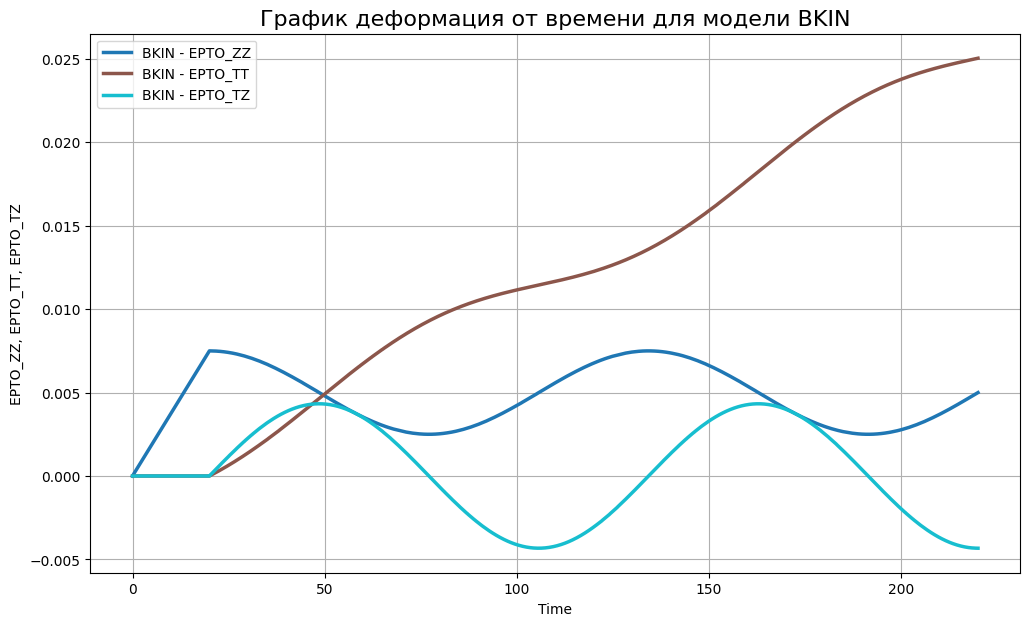

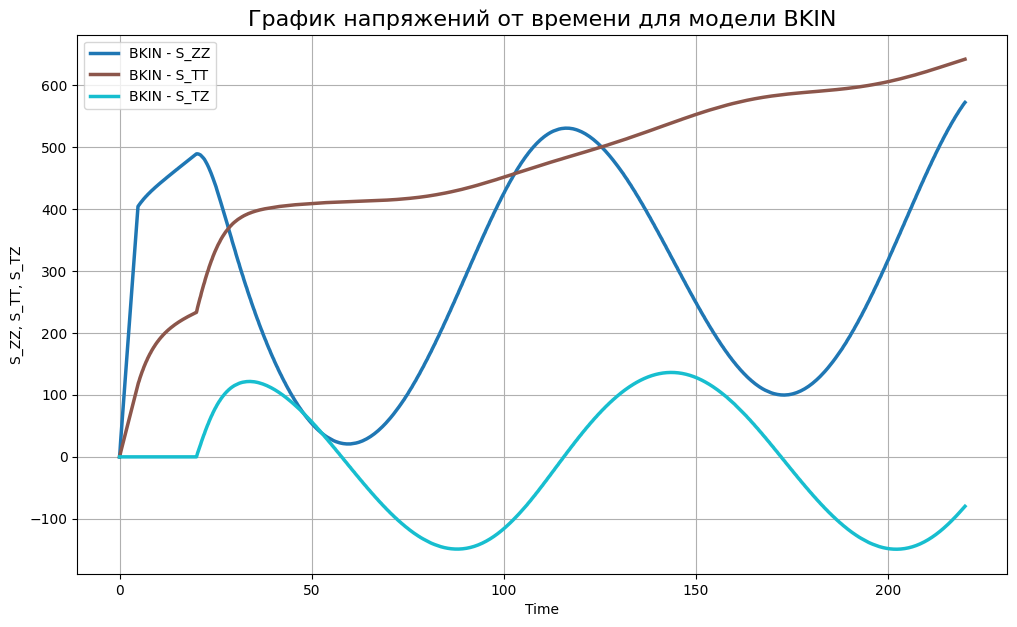

In [5]:
from core.visualizer import plot_xy


model_name = 'BKIN'

plot_xy([
        (model_name, numerical_experiment_bkin)
    ],
    'Time',
    ['EPTO_ZZ', 'EPTO_TT', 'EPTO_TZ'],
    f'График деформация от времени для модели {model_name}'
)

plot_xy([
        (model_name, numerical_experiment_bkin)
    ],
    'Time',
    ['S_ZZ', 'S_TT', 'S_TZ'],
    f'График напряжений от времени для модели {model_name}'
)

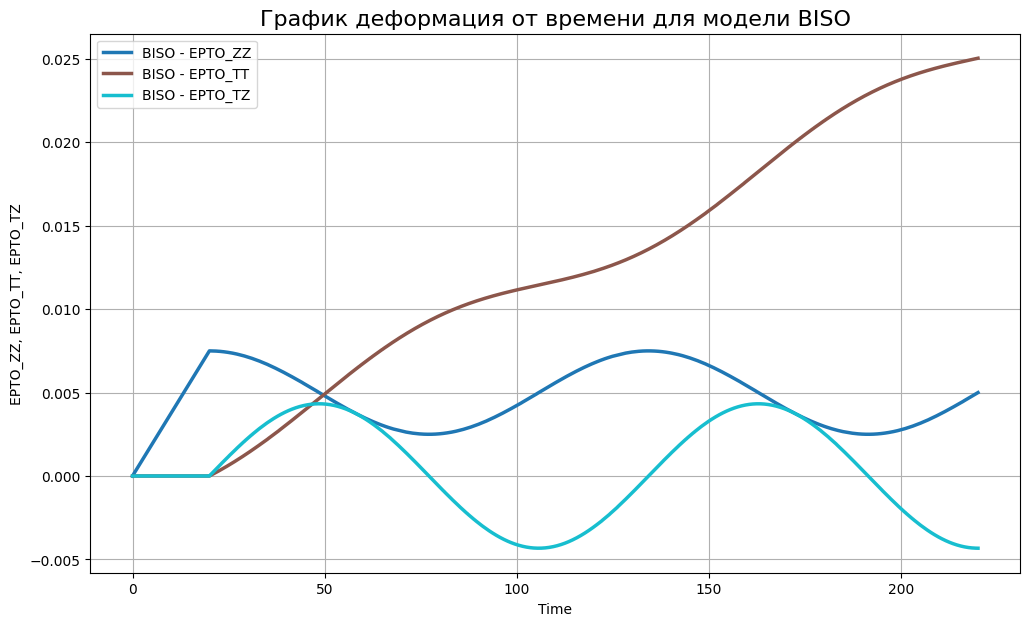

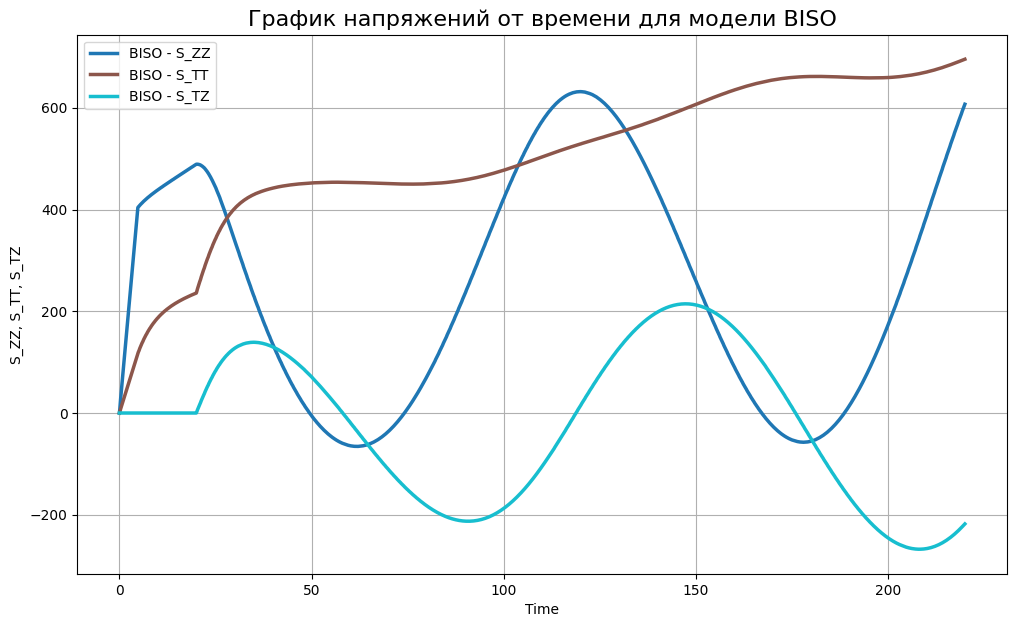

In [6]:
model_name = 'BISO'

plot_xy([
        (model_name, numerical_experiment_biso)
    ],
    'Time',
    ['EPTO_ZZ', 'EPTO_TT', 'EPTO_TZ'],
    f'График деформация от времени для модели {model_name}'
)

plot_xy([
        (model_name, numerical_experiment_biso)
    ],
    'Time',
    ['S_ZZ', 'S_TT', 'S_TZ'],
    f'График напряжений от времени для модели {model_name}'
)

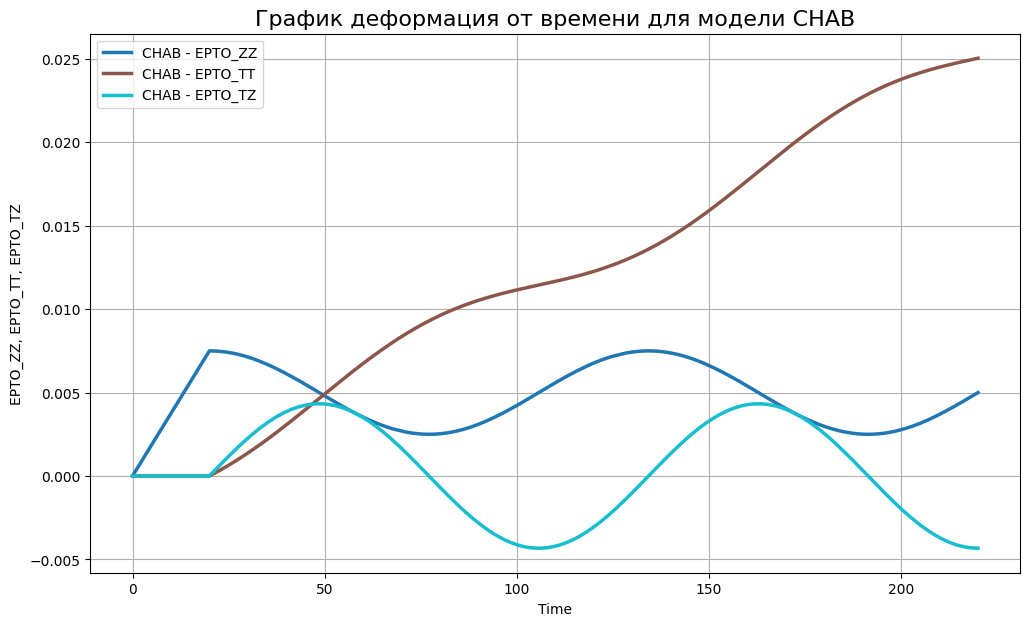

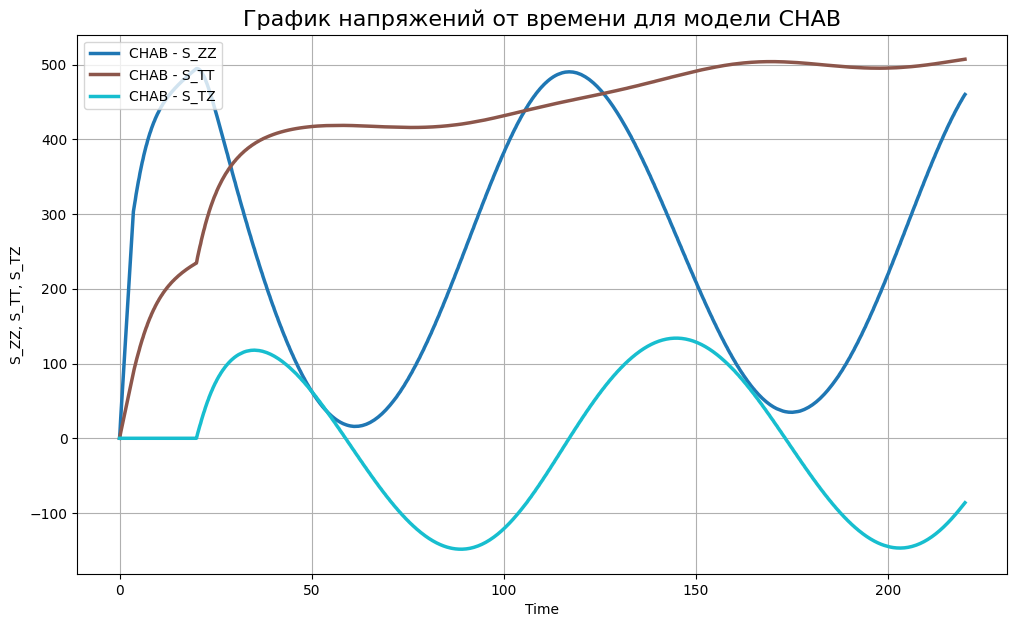

In [7]:
model_name = 'CHAB'

plot_xy([
        (model_name, numerical_experiment_chab)
    ],
    'Time',
    ['EPTO_ZZ', 'EPTO_TT', 'EPTO_TZ'],
    f'График деформация от времени для модели {model_name}'
)

plot_xy([
        (model_name, numerical_experiment_chab)
    ],
    'Time',
    ['S_ZZ', 'S_TT', 'S_TZ'],
    f'График напряжений от времени для модели {model_name}'
)

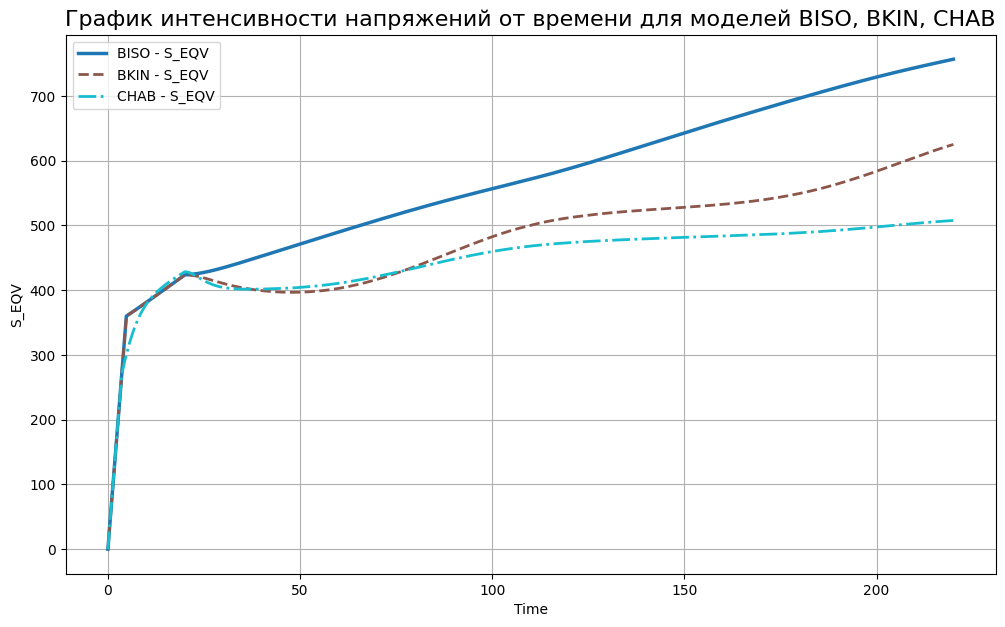

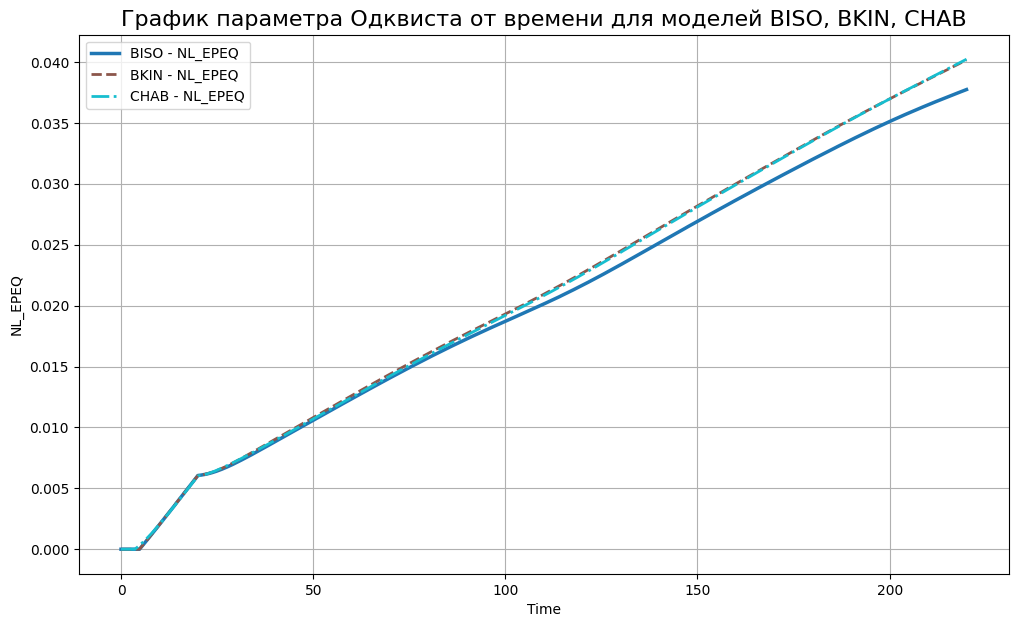

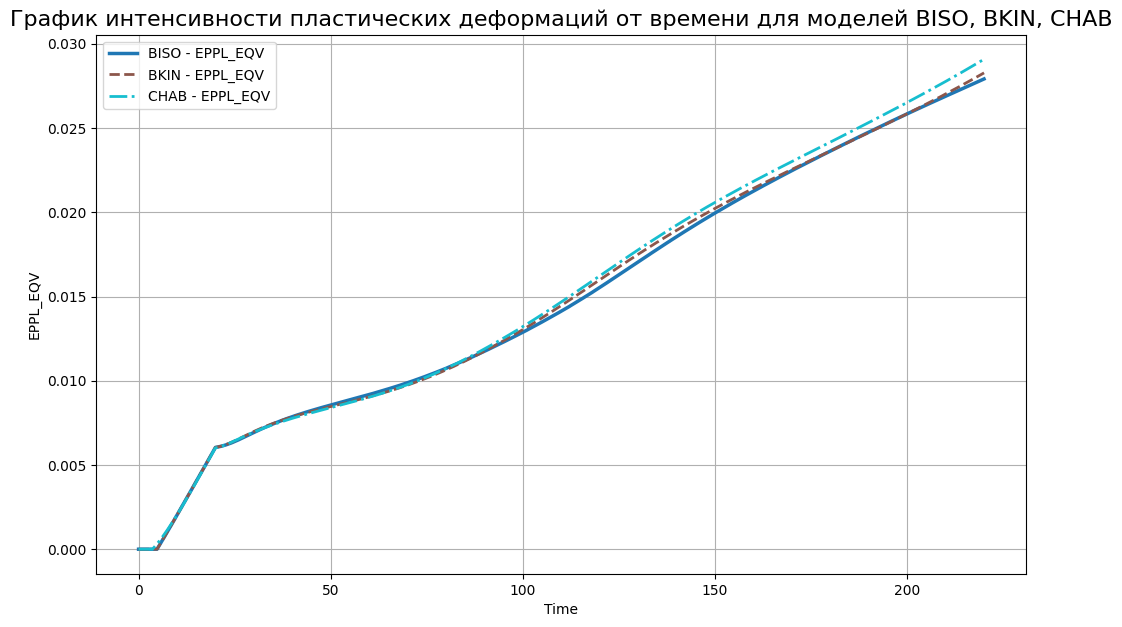

In [11]:
plot_xy([
        ('BISO', numerical_experiment_biso),
        ('BKIN', numerical_experiment_bkin),
        ('CHAB', numerical_experiment_chab)
    ],
    'Time',
    ['S_EQV'],
    f'График интенсивности напряжений от времени для моделей BISO, BKIN, CHAB'
)

plot_xy([
        ('BISO', numerical_experiment_biso),
        ('BKIN', numerical_experiment_bkin),
        ('CHAB', numerical_experiment_chab)
    ],
    'Time',
    ['NL_EPEQ'],
    f'График параметра Одквиста от времени для моделей BISO, BKIN, CHAB'
)

plot_xy([
        ('BISO', numerical_experiment_biso),
        ('BKIN', numerical_experiment_bkin),
        ('CHAB', numerical_experiment_chab)
    ],
    'Time',
    ['EPPL_EQV'],
    f'График интенсивности пластических деформаций от времени для моделей BISO, BKIN, CHAB'
)

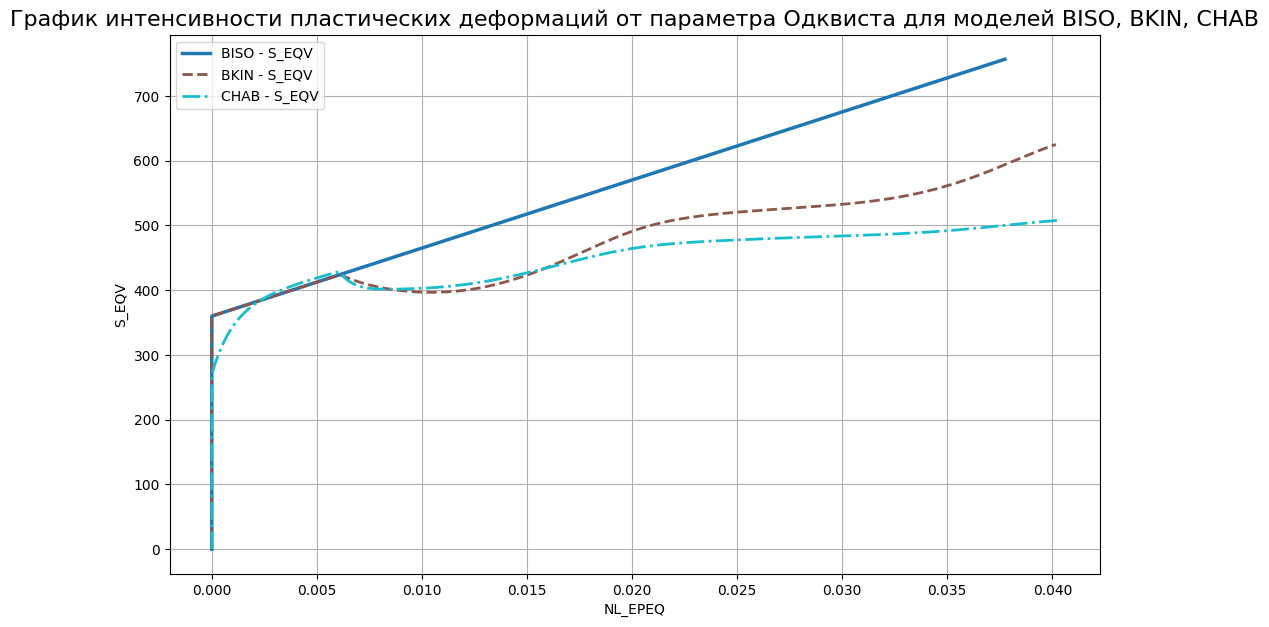

In [12]:
plot_xy([
        ('BISO', numerical_experiment_biso),
        ('BKIN', numerical_experiment_bkin),
        ('CHAB', numerical_experiment_chab)
    ],
    'NL_EPEQ',
    ['S_EQV'],
    f'График интенсивности пластических деформаций от параметра Одквиста для моделей BISO, BKIN, CHAB'
)

## Теоретическое обоснование численного дифференцирования

### 1. Численное дифференцирование на равномерной сетке

После фильтрации данных с помощью функции `load_and_filter_ansys_csv`, мы получаем набор данных на **равномерной временной сетке** с постоянным шагом $h = \Delta t$. Для вычисления производной функции $f(t)$ по времени используется **центральная разностная схема**, реализованная в `numpy.gradient`.

Для любой внутренней точки $t_i$ производная аппроксимируется как:
$$
f'(t_i) \approx \frac{f(t_{i+1}) - f(t_{i-1})}{2h}
$$

#### Вывод погрешности для первой производной (центральная разностная схема)

Центральная разностная схема аппроксимирует производную в точке $t_i$ с использованием значений в соседних точках $t_{i+1} = t_i + h$ и $t_{i-1} = t_i - h$:
$$
f'(t_i)_{\text{числ}} = \frac{f(t_{i+1}) - f(t_{i-1})}{2h}
$$
Для вывода погрешности разложим значения $f(t_{i+1})$ и $f(t_{i-1})$ в ряд Тейлора в окрестности точки $t_i$:
$$
f(t_{i+1}) = f(t_i) + f'(t_i)h + \frac{f''(t_i)}{2!}h^2 + \frac{f'''(t_i)}{3!}h^3 + \frac{f^{(4)}(t_i)}{4!}h^4 + O(h^5) \quad \quad (1)
$$
$$
f(t_{i-1}) = f(t_i) - f'(t_i)h + \frac{f''(t_i)}{2!}h^2 - \frac{f'''(t_i)}{3!}h^3 + \frac{f^{(4)}(t_i)}{4!}h^4 - O(h^5) \quad \quad (2)
$$
Вычтем уравнение (2) из уравнения (1):
$$
f(t_{i+1}) - f(t_{i-1}) = 2f'(t_i)h + 2\frac{f'''(t_i)}{6}h^3 + O(h^5)
$$
Теперь выразим численное значение производной, разделив на $2h$:
$$
\frac{f(t_{i+1}) - f(t_{i-1})}{2h} = f'(t_i) + \frac{f'''(t_i)}{6}h^2 + O(h^4)
$$
Абсолютная погрешность — это разница между численным и истинным значением:
$$
\text{Error}(f'(t_i)) = f'(t_i)_{\text{числ}} - f'(t_i)_{\text{истин}} = \frac{f(t_{i+1}) - f(t_{i-1})}{2h} - f'(t_i)
$$
Таким образом, главный член погрешности равен:
$$
\boxed{ \text{Error}(f'(t_i)) \approx \frac{h^2}{6} f'''(t_i) }
$$
Погрешность имеет **второй порядок точности** ($O(h^2)$).

#### Вывод погрешности для второй производной (центральная разностная схема)

Вторая производная аппроксимируется как:
$$
f''(t_i)_{\text{числ}} = \frac{f(t_{i+1}) - 2f(t_i) + f(t_{i-1})}{h^2}
$$
Для вывода погрешности теперь **сложим** уравнения (1) и (2) из разложения в ряд Тейлора:
$$
f(t_{i+1}) + f(t_{i-1}) = 2f(t_i) + 2\frac{f''(t_i)}{2}h^2 + 2\frac{f^{(4)}(t_i)}{24}h^4 + O(h^6)
$$
Перегруппируем члены, чтобы выделить аппроксимацию второй производной:
$$
f(t_{i+1}) - 2f(t_i) + f(t_{i-1}) = f''(t_i)h^2 + \frac{f^{(4)}(t_i)}{12}h^4 + O(h^6)
$$
Разделим на $h^2$:
$$
\frac{f(t_{i+1}) - 2f(t_i) + f(t_{i-1})}{h^2} = f''(t_i) + \frac{f^{(4)}(t_i)}{12}h^2 + O(h^4)
$$
Отсюда погрешность равна:
$$
\boxed{ \text{Error}(f''(t_i)) \approx \frac{h^2}{12} f^{(4)}(t_i) }
$$
Погрешность также имеет **второй порядок точности** ($O(h^2)$).

#### Вывод погрешности для третьей производной

Для третьей производной нам потребуется разложение в ряд Тейлора для точек $t_{i+2}$ и $t_{i-2}$:
$$
f(t_{i+2}) = f(t_i+2h) = f(t_i) + 2f'(t_i)h + \frac{4f''(t_i)}{2}h^2 + \frac{8f'''(t_i)}{6}h^3 + \dots
$$
$$
f(t_{i-2}) = f(t_i-2h) = f(t_i) - 2f'(t_i)h + \frac{4f''(t_i)}{2}h^2 - \frac{8f'''(t_i)}{6}h^3 + \dots
$$
Центральная разностная схема для третьей производной имеет вид:
$$
f'''(t_i)_{\text{числ}} = \frac{f(t_{i+2}) - 2f(t_{i+1}) + 2f(t_{i-1}) - f(t_{i-2})}{2h^3}
$$
Чтобы вывести погрешность, нужно выполнить комбинацию $(f(t_{i+2}) - f(t_{i-2})) - 2(f(t_{i+1}) - f(t_{i-1}))$. После очень громоздких алгебраических преобразований с рядами Тейлора до $O(h^5)$ можно показать, что:
$$
(f(t_{i+2}) - \dots - f(t_{i-2})) = 2h^3 f'''(t_i) + \frac{h^5}{2}f^{(5)}(t_i) + \dots
$$
Разделив на $2h^3$, получаем главный член погрешности:
$$
\boxed{ \text{Error}(f'''(t_i)) \approx \frac{h^2}{4} f^{(5)}(t_i) }
$$
Погрешность снова имеет **второй порядок точности** ($O(h^2)$), но, как видно, коэффициент перед $h^2$ (1/4) больше, чем для первой (1/6) и второй (1/12) производных, что указывает на рост численной ошибки.

---

### 2. Производная по длине дуги (дифференцирование сложной функции)

Нас интересует производная $g(s) = \frac{\mathrm{d}f}{\mathrm{d}s}$, где $f$ и $s$ являются функциями времени $t$. Используя правило дифференцирования сложной функции:
$$
\frac{\mathrm{d}f}{\mathrm{d}s} = \frac{\mathrm{d}f/\mathrm{d}t}{\mathrm{d}s/\mathrm{d}t}
$$

#### Оценка погрешности производной `df/ds`

Обозначим $u = f'(t)$ и $v = s'(t)$. Численные значения содержат ошибки: $u_c = u + E_u$ и $v_c = v + E_v$. Численное значение производной $g_c$:
$$
g_c = \frac{u_c}{v_c} = \frac{u + E_u}{v + E_v} = \frac{1}{v} (u + E_u) \left(1 + \frac{E_v}{v}\right)^{-1}
$$
Используя разложение в ряд $(1+x)^{-1} \approx 1 - x$ для малых $x = E_v/v$, получаем:
$$
g_c \approx \frac{1}{v} (u + E_u) (1 - E_v/v) \approx \frac{u}{v} + \frac{E_u}{v} - \frac{u}{v}\frac{E_v}{v}
$$
Абсолютная погрешность $\text{Error}(g) = g_c - g \approx \frac{E_u}{v} - g\frac{E_v}{v}$. Переходя к исходным обозначениям:
$$
\text{Error}\left(\frac{\mathrm{d}f}{\mathrm{d}s}\right) \approx \frac{1}{s'(t)} \left( \text{Error}(f'(t)) - \frac{\mathrm{d}f}{\mathrm{d}s} \cdot \text{Error}(s'(t)) \right)
$$
Взяв модуль, получаем формулу для оценки погрешности. Главный вывод состоит в том, что порядок точности сохраняется. Так как $\text{Error}(f'(t))$ и $\text{Error}(s'(t))$ имеют порядок $O(h^2)$, то и $\text{Error}\left(\frac{\mathrm{d}f}{\mathrm{d}s}\right)$ также имеет порядок **$O(h^2)$**.

#### Погрешности высших производных по длине дуги

Для второй производной $\frac{\mathrm{d}^2f}{\mathrm{d}s^2}$ используется правило:
$$
\frac{\mathrm{d}^2f}{\mathrm{d}s^2} = \frac{\mathrm{d}}{\mathrm{d}s}\left(\frac{\mathrm{d}f}{\mathrm{d}s}\right) = \frac{\frac{\mathrm{d}}{\mathrm{d}t}\left(\frac{\mathrm{d}f/\mathrm{d}t}{\mathrm{d}s/\mathrm{d}t}\right)}{\mathrm{d}s/\mathrm{d}t} = \frac{f''(t)s'(t) - f'(t)s''(t)}{(s'(t))^3}
$$
При численном расчете в эту формулу подставляются приближенные значения производных по $t$, каждое из которых имеет погрешность $O(h^2)$. В результате комбинации этих погрешностей итоговая погрешность для $\frac{\mathrm{d}^2f}{\mathrm{d}s^2}$ **также будет иметь порядок $O(h^2)$**.

**Общий вывод:** При использовании центральных разностных схем для вычисления производных по времени $t$, производные любого порядка по длине дуги $s$ сохраняют **второй порядок точности $O(h^2)$**. Однако с ростом порядка производной увеличивается сложность коэффициента перед $h^2$ и растет чувствительность к численным ошибкам и "шуму" в исходных данных.